In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../../data/_data.csv")

In [21]:
df = df.drop(columns = ["Unnamed: 0", "Тип", "Метро", "Площадь, м2", "Телефоны", "Описание", "Площадь комнат, м2", "Серия дома", "Высота потолков, м", "Ссылка на объявление"])
df = df.rename(columns = {'ID  объявления': 'id'})

In [ ]:
## Комнаты

df["rooms_count"] = df["Количество комнат"].str.replace(r"[^\d.]", "", regex = True)

df["types_room"] = df["Количество комнат"].str.replace(r"[^\D]", "", regex = True)
df["types_room"] = df["types_room"].str.replace(",", "").str.strip()
df["types_room"] = df["types_room"].replace('', pd.NA)

def check_isolated_room(types_room, rooms_count):
    if pd.isna(types_room):
        return 1 if (rooms_count == "1") else None
    if rooms_count == "2" and 'Оба варианта' in str(types_room):
        return 0
    return 1 if ('Изолированная' in str(types_room) or 'Оба варианта' in str(types_room)) else 0

def check_adjacent_room(types_room, rooms_count):
    if pd.isna(types_room):
        return 0 if rooms_count == "1" else None
    if rooms_count == "1":
        return 0
    if rooms_count == "2" and 'Оба варианта' in str(types_room):
        return 1
    return  1 if ('Смежная' in str(types_room) or 'Оба варианта' in str(types_room)) else 0

df['is_isolated'] = df.apply(lambda row: check_isolated_room(row['types_room'], row['rooms_count']), axis=1)
df['is_adjacent'] = df.apply(lambda row: check_adjacent_room(row['types_room'], row['rooms_count']), axis=1)


# fillna
# fillna



In [ ]:
## Дом

df["floor"] = df["Дом"].str.replace(r"[^\d/]", "", regex = True)
floor = df['floor'].str.split('/')
df["floor"] = floor.str[0].astype(int)
df["floors_in_house"] = floor.str[-1].astype(int)


house_types = df["Дом"].str.replace(r"[^\D]", "", regex = True)
house_types = house_types.str.replace("/", "", regex = True)
house_types = house_types.str.replace(",", "", regex = True).str.strip()
house_types = house_types.replace('', pd.NA)
house_types = house_types.replace('- Монолитный', "Монолитный")
house_types = house_types.replace('старый фонд', 'Сталинский')
house_types = house_types.replace('Газобетонный блок', 'Деревянный')
house_types = house_types.replace('Щитовой', 'Панельный')
house_types = house_types.replace('Деревянный', 'Панельный')
house_types = house_types.replace('Блочный', 'Панельный')
house_types = house_types.replace('Сталинский', 'Кирпичный')
house_types = house_types.replace('Монолитно-кирпичный', 'Монолитный')
df["house_tipe"] = house_types.replace({'Панельный': 0, 'Кирпичный': 1, 'Монолитный': 2})

# fillna

In [25]:
## Парковка
df["parking"] = df["Парковка"].replace({'наземная': 0, 'открытая': 1, 'на крыше': 2, 'многоуровневая': 3, 'подземная': 4})


In [26]:
## Ремонт

df["renovation"] = df["Ремонт"].replace({'Без ремонта': 0, 'Косметический': 1, 'Евроремонт': 2, 'Дизайнерский': 3})

# fillna

In [27]:
## Балкон

def check_loggia(x):
    if pd.isna(x):
        return None
    return 1 if 'Лоджия' in str(x) else 0

def check_balcony(x):
    if pd.isna(x):
        return None
    return 1 if 'Балкон' in str(x) else 0

df['is_loggia'] = df['Балкон'].apply(check_loggia)
df['is_balcony'] = df['Балкон'].apply(check_balcony)


# fillna
# fillna


In [ ]:
## Окна

def check_view_of_courtyard(x):
    if pd.isna(x):
        return None
    return 1 if 'двор' in str(x) else 0

def check_view_of_street(x):
    if pd.isna(x):
        return None
    return 1 if 'улицу' in str(x) else 0

df['view_of_courtyard'] = df['Окна'].apply(check_view_of_courtyard)
df['view_of_street'] = df['Окна'].apply(check_view_of_street)


# fillna
# fillna

In [ ]:
## Санузел

def check_combined_bathroom(x):
    if pd.isna(x):
        return None
    return 1 if 'Совмещенный' in str(x) else 0

def check_separate_bathroom(x):
    if pd.isna(x):
        return None
    return 1 if 'Раздельный' in str(x) else 0

df['combined_bathroom'] = df['Санузел'].apply(check_combined_bathroom)
df['separate_bathroom'] = df['Санузел'].apply(check_separate_bathroom)

# fillna
# fillna

In [ ]:
## Можно с детьми/животными

def check_child(x):
    if pd.isna(x):
        return None
    return 1 if 'детьми' in str(x) else 0

def check_pet(x):
    if pd.isna(x):
        return None
    return 1 if 'животными' in str(x) else 0

df['is_child'] = df['Можно с детьми/животными'].apply(check_child)
df['is_pet'] = df['Можно с детьми/животными'].apply(check_pet)

# fillna
# fillna

In [ ]:
## Дополнительно

def check_room_furniture(x):
    if pd.isna(x):
        return None
    return 1 if 'Мебель в комнатах' in str(x) else 0

def check_kitchen_furniture(x):
    if pd.isna(x):
        return None
    return 1 if 'Мебель на кухне' in str(x) else 0

def check_bath(x):
    if pd.isna(x):
        return None
    return 1 if 'Ванна' in str(x) else 0

def check_shower_cabin(x):
    if pd.isna(x):
        return None
    return 1 if 'Душевая кабина' in str(x) else 0

def check_washing_machine(x):
    if pd.isna(x):
        return None
    return 1 if 'Стиральная машина' in str(x) else 0

def check_air_conditioner(x):
    if pd.isna(x):
        return None
    return 1 if 'Кондиционер' in str(x) else 0

def check_dishwasher(x):
    if pd.isna(x):
        return None
    return 1 if 'Посудомоечная машина' in str(x) else 0

def check_tv(x):
    if pd.isna(x):
        return None
    return 1 if 'Телевизор' in str(x) else 0

def check_fridge(x):
    if pd.isna(x):
        return None
    return 1 if 'Холодильник' in str(x) else 0

def check_internet(x):
    if pd.isna(x):
        return None
    return 1 if 'Интернет' in str(x) else 0

def check_telephone(x):
    if pd.isna(x):
        return None
    return 1 if 'Телефон' in str(x) else 0

df['room_furniture'] = df['Дополнительно'].apply(check_room_furniture)
df['kitchen_furniture'] = df['Дополнительно'].apply(check_kitchen_furniture)
df['bath'] = df['Дополнительно'].apply(check_bath)
df['shower_cabin'] = df['Дополнительно'].apply(check_shower_cabin)
df['washing_machine'] = df['Дополнительно'].apply(check_washing_machine)
df['air_conditioner'] = df['Дополнительно'].apply(check_air_conditioner)
df['dishwasher'] = df['Дополнительно'].apply(check_dishwasher)
df['tv'] = df['Дополнительно'].apply(check_tv)
df['fridge'] = df['Дополнительно'].apply(check_fridge)
df['internet'] = df['Дополнительно'].apply(check_internet)
df['telephone'] = df['Дополнительно'].apply(check_telephone)

# fillna
# fillna
# fillna
# fillna
# fillna
# fillna
# fillna
# fillna
# fillna
# fillna
# fillna

In [32]:
## Лифт 

def check_passenger_lift(x):
    if pd.isna(x):
        return None
    return 1 if 'Пасс' in str(x) else 0

def check_freight_lift(x):
    if pd.isna(x):
        return None
    return 1 if 'Груз' in str(x) else 0

df['is_passenger_lift'] = df['Лифт'].apply(check_passenger_lift)
df['is_freight_lift'] = df['Лифт'].apply(check_freight_lift)


# fillna
# fillna

In [33]:
## Мусоропровод

df["garbage_chute"] = df["Мусоропровод"].replace({'Да': 1, 'Нет': 0})

# fillna


In [ ]:
## Удаление лишних колонок
df = df.drop(columns =["Мусоропровод", 'Лифт', "Можно с детьми/животными", 'Санузел', 'Окна', 'Балкон', "Ремонт", "types_room", "Количество комнат", "Парковка", "Дополнительно", "Дом"])
df = df.drop(columns =["Адрес", 'Цена', "Название ЖК"])

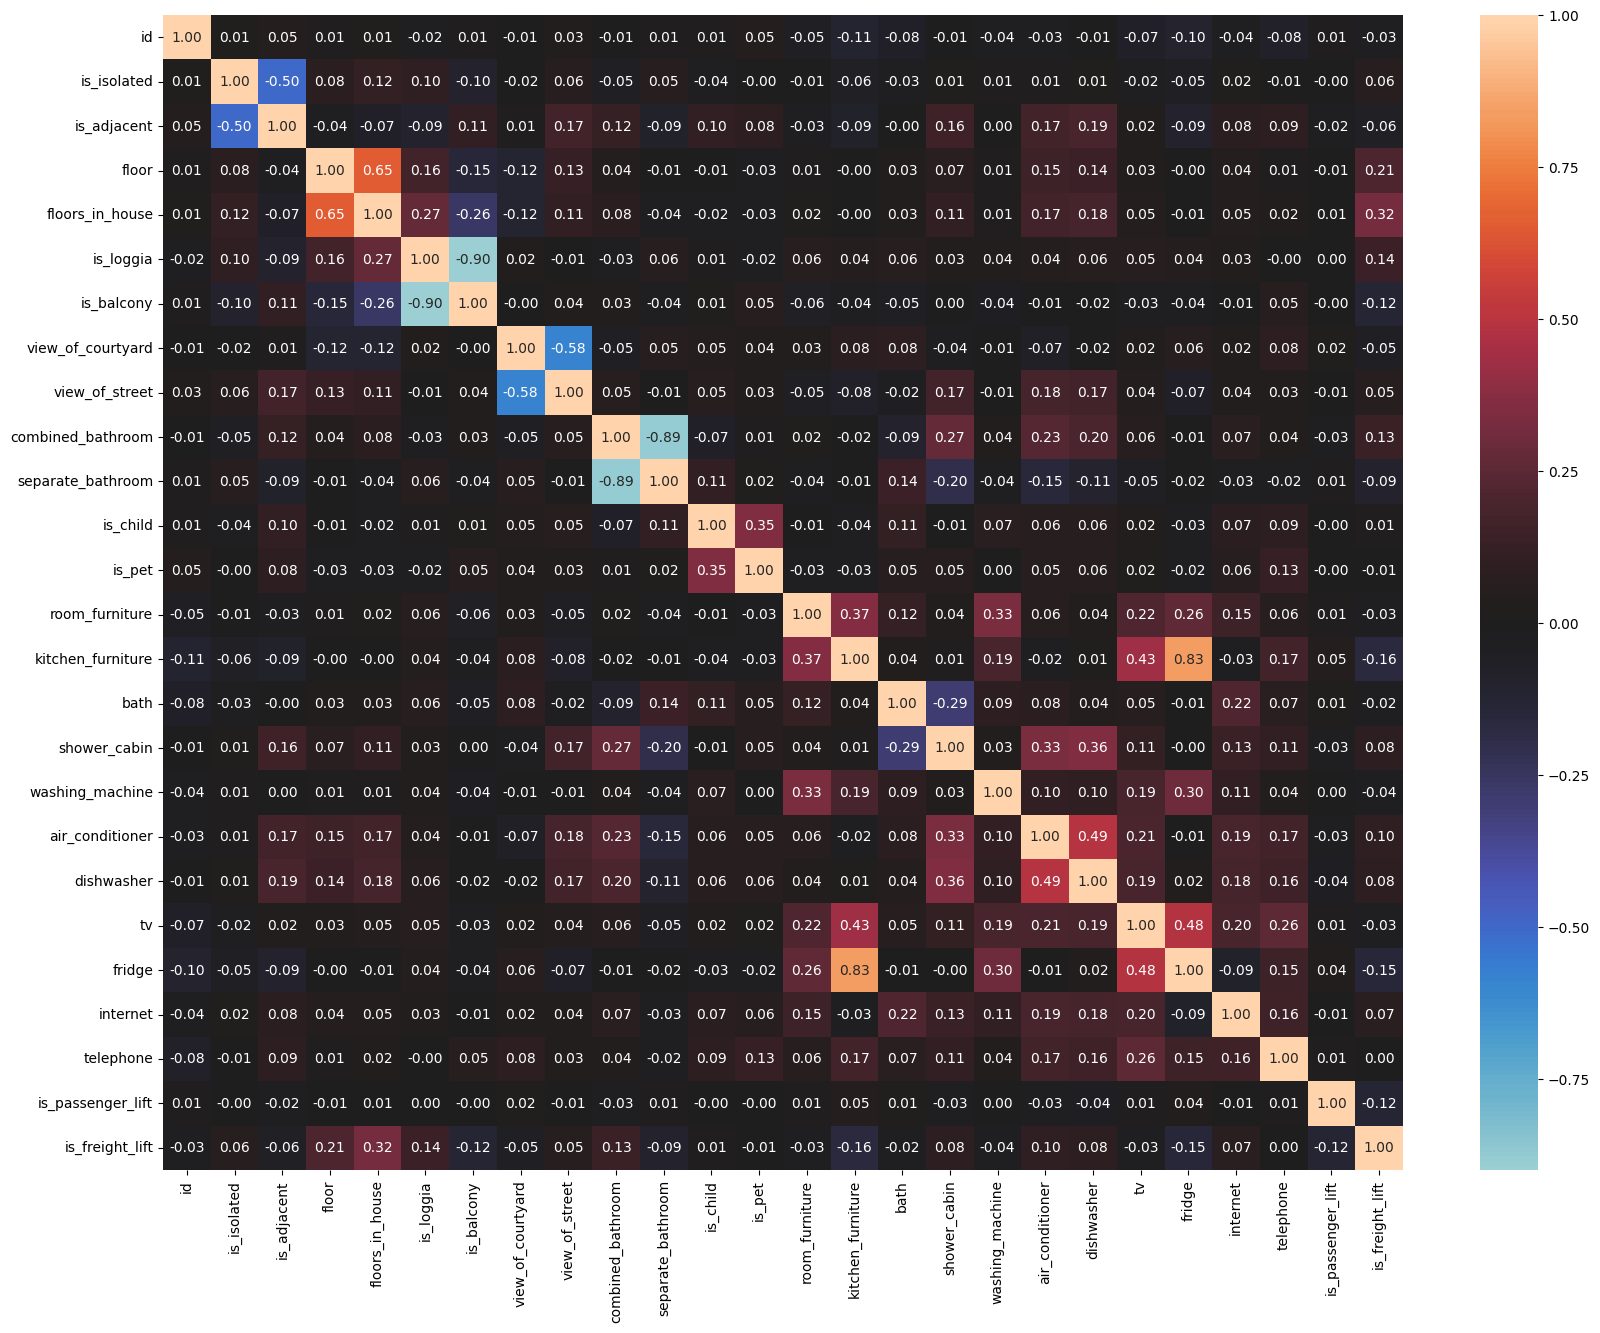

In [36]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(numeric_only = True), annot = True, center = 0, fmt = ".2f");

In [37]:
df.to_csv('../../tmp_data/vanya_processed_part_1.csv', index=False)